# Practice Quiz — Lecture 18 / Assignment 8

**Read first:** This practice quiz mirrors the tasks from your Lecture 18 and the related assignment. Answer **only using pandas / numpy / matplotlib** as shown in lecture. For plotting, use **matplotlib.pyplot** and the **DataFrame `.plot()`** method where asked. Do **not** use seaborn.

**Files assumed:**
- `delhi_2017_weather.csv` — has at least `time`, `temperature`, and `wind_speed` columns.
- `fx_rates.csv` — has date/time and columns for `EUR_USD` and `GBP_USD` (or similarly named).

Replace paths/column names as needed to match your actual files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 120

## Questions

### 1) Quadratic model: coefficients and plotting fix
You are given arrays `x` and `y` and a code cell that computes coefficients of a quadratic model
$y_i \approx a x_i^2 + b x_i + c$.

**(a)** Compute the least–squares coefficients `(a, b, c)`.

**(b)** The next cell produces a scatter of the raw points and a line for the model prediction, but the line is clearly wrong because of how it's drawn. Modify the plotting code so the prediction curve is correct.

(a, b, c) = (np.float64(0.8254025468807393), np.float64(-0.30800711631932326), np.float64(1.3577934101238245))


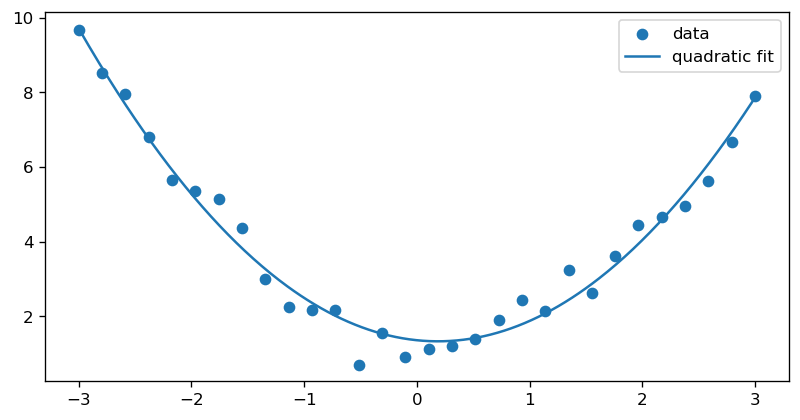

In [58]:
# --- your work for Q1 ---
# Example toy data (replace with the arrays provided on your quiz):
x = np.linspace(-3, 3, 30)
rng = np.random.default_rng(0)
y = 0.8*x**2 - 0.3*x + 1.5 + rng.normal(0, 0.5, size=x.size)
# (a) coefficients via np.polyfit (degree 2)
coefs = np.polyfit(x, y, deg=2)
a, b, c = coefs
print('(a, b, c) =', (a, b, c))

# (b) correct curve: evaluate on a sorted grid
xx = np.linspace(np.min(x), np.max(x), 400)
yy = a*xx**2 + b*xx + c
fig, ax = plt.subplots()
ax.scatter(x, y, label='data')
ax.plot(xx, yy, label='quadratic fit')
ax.legend()
plt.show()

### 2) Weather CSV + single figure with two lines (DataFrame `.plot()`)
Read `delhi_2017_weather.csv` into a DataFrame named `wx`. Using the **DataFrame's** `.plot()` method (not `plt.plot` directly), make a **single** line plot with two series:
- time vs temperature
- time vs wind speed

If needed, parse the time column to `datetime` and set it as the index so that `.plot()` uses it on the x‑axis.

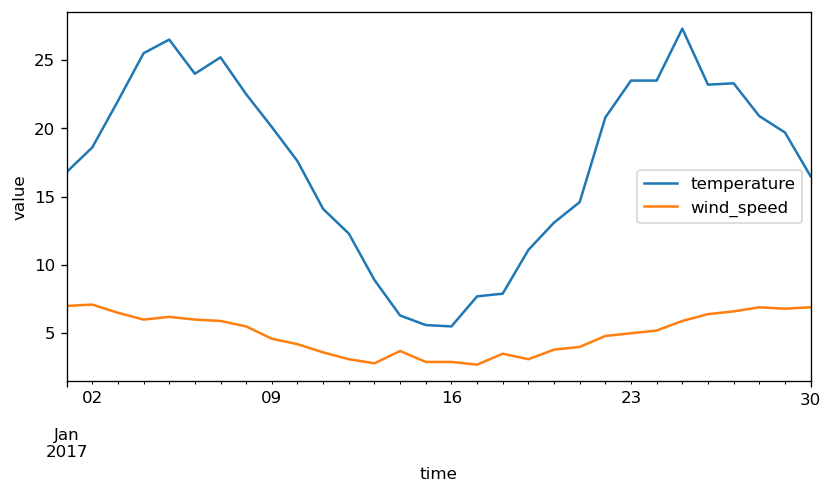

In [53]:
# --- your work for Q2 ---
wx = pd.read_csv("delhi_2017_weather.csv")
wx["date"] = pd.to_datetime(wx["time"])
ax = wx[ [ "date", "temperature", "wind_speed"]].set_index("date").plot()
ax.set_xlabel('time')
ax.set_ylabel('value')
plt.show()

### 3) Currency conversion rates: non‑dimensional percentage growth
Read `fx_rates.csv` into `fx`. Assume it contains columns for **Euro→USD** and **British Pound→USD**. Create two new columns with **non‑dimensional percentage growth** (relative change from the first value) for each currency, and plot both growth series on a single figure. (*You may use either `matplotlib.pyplot` or a DataFrame `.plot()`.*)

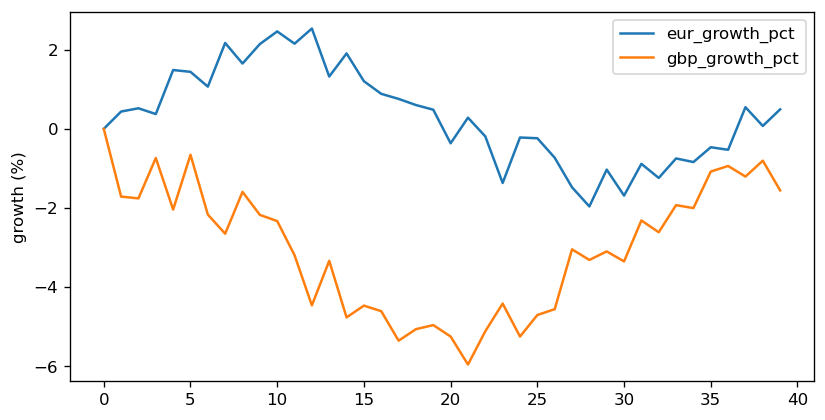

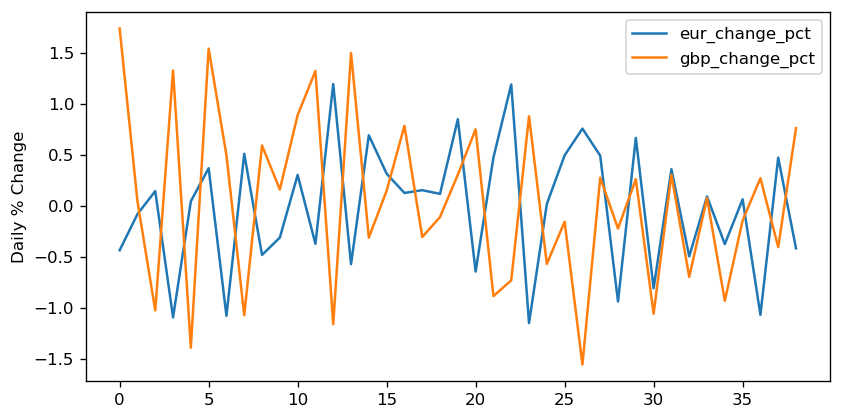

In [57]:
# --- your work for Q3 ---
fx = pd.read_csv('fx_rates.csv')
fx['date'] = pd.to_datetime(fx['date'])
fx['eur_growth_pct'] = (fx['EUR_USD'] / fx['EUR_USD'].iloc[0] - 1.0) * 100
fx['gbp_growth_pct'] = (fx['GBP_USD'] / fx['GBP_USD'].iloc[0] - 1.0) * 100
fx[['eur_growth_pct','gbp_growth_pct']].plot()
plt.ylabel('growth (%)')
plt.show()

fx_new = fx.sort_values(by="date", ascending=False)
# --- Question 3: Daily Percentage Change using diff() and shift() ---

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read and prepare the data
fx = pd.read_csv("fx_rates.csv")
fx['date'] = pd.to_datetime(fx['date'])
fx['time'] = fx['date']

# Step 3: Compute the difference from the previous day
fx_new['eur_diff'] = fx_new['EUR_USD'].diff()
fx_new['gbp_diff'] = fx_new['GBP_USD'].diff()

# Step 4: Compare each difference to the previous day's value (using .shift)
fx_new['eur_prev'] = fx_new['EUR_USD'].shift(1)
fx_new['gbp_prev'] = fx_new['GBP_USD'].shift(1)

# Step 5: Compute daily % change
fx_new['eur_change_pct'] = (fx_new['eur_diff'] / fx_new['eur_prev']) * 100
fx_new['gbp_change_pct'] = (fx_new['gbp_diff'] / fx_new['gbp_prev']) * 100

# Step 6: Plot daily percentage change
fx_new[['eur_change_pct', 'gbp_change_pct']].plot()
plt.ylabel("Daily % Change")
plt.show()



### 4) Boolean mask column
Continuing with the `fx` DataFrame, create a new **Boolean** column named `eur_above_thr` that is `True` when the **Euro→USD** rate is strictly greater than a value you specify in `thr`.

In [55]:
# --- your work for Q4 ---
eur_above_thr = abs(fx_new["eur_change_pct"])>0.5
print(eur_above_thr)

39    False
38    False
37    False
36     True
35    False
34    False
33    False
32    False
31    False
30     True
29     True
28     True
27    False
26     True
25    False
24    False
23     True
22     True
21    False
20     True
19     True
18    False
17    False
16    False
15    False
14     True
13     True
12     True
11    False
10    False
9     False
8     False
7      True
6      True
5     False
4     False
3      True
2     False
1     False
0     False
Name: eur_change_pct, dtype: bool


### 5) Highlight regions with `plt.fill_between`
Make a line plot of the **Euro→USD** series and **highlight** the regions where `eur_above_thr` is `True` using `plt.fill_between`.

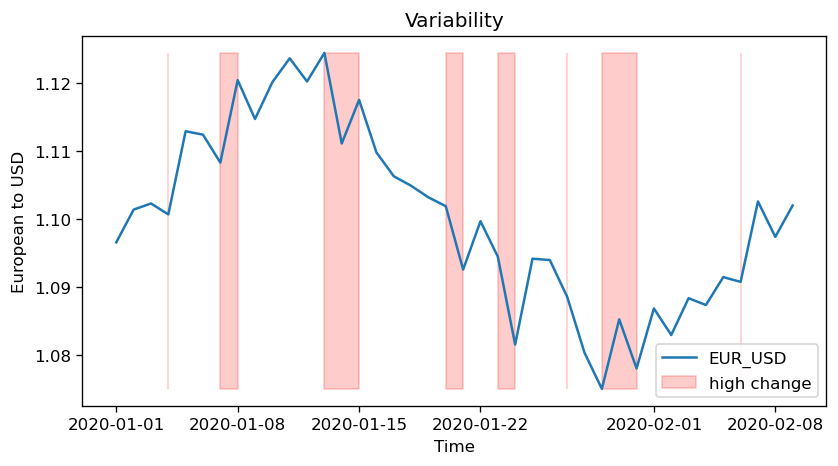

In [59]:
# --- your work for Q5 ---
plt.plot("date", "EUR_USD", data = fx_new)
plt.xlabel("Time")
plt.ylabel("European to USD")
plt.title("Variability")

x_vals = fx_new["date"]
y_vals = fx_new["EUR_USD"]
condition = eur_above_thr

plt.fill_between(x = x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red", label="high change")

plt.legend()
plt.show()

### 6) Finite‑difference derivative of sine
Create a DataFrame with columns:
- `time`: evenly spaced points from 0 to $2\pi$
- `sin`: $\sin(\text{time})$
- `cos`: $\cos(\text{time})$

Using `.diff()` compute a new column `d_sin_dt` with the forward‑difference approximation:
$$\frac{\sin(t_{k+1}) - \sin(t_k)}{t_{k+1}-t_k}$$

Plot **on one figure**: `time` vs `cos` and `time` vs `d_sin_dt`. From calculus, these should be close.

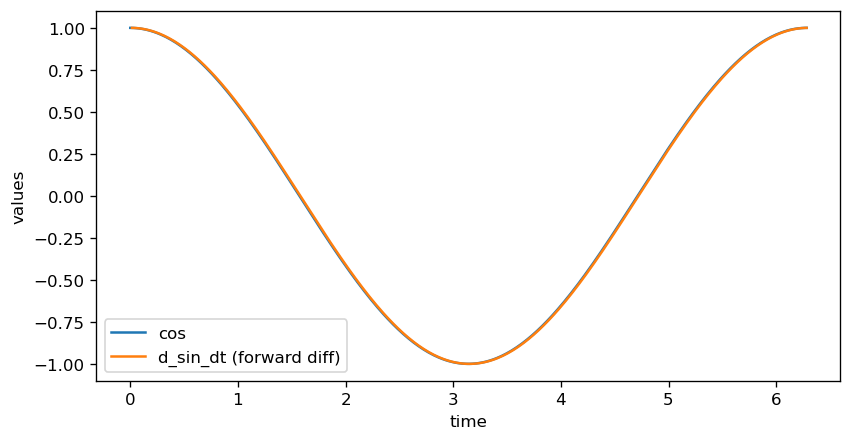

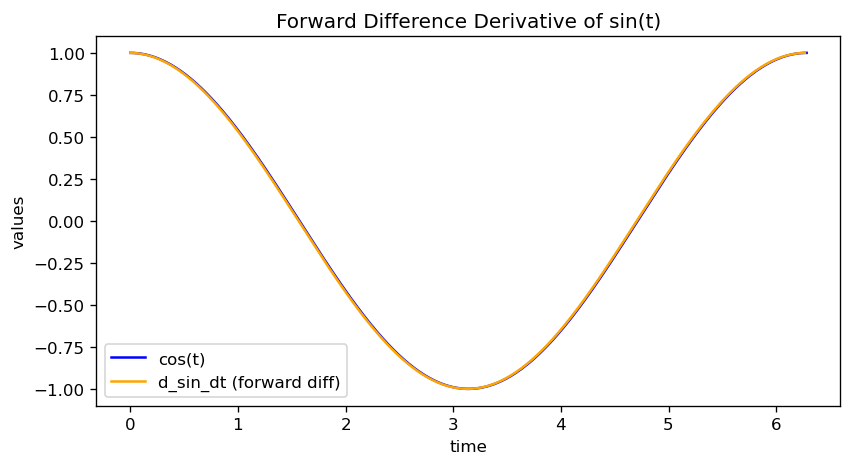

In [49]:
# --- your work for Q6 ---
n = 400
t = np.linspace(0, 2*np.pi, n)
df = pd.DataFrame({'time': t})
df['sin'] = np.sin(df['time'])
df['cos'] = np.cos(df['time'])

# forward difference; last value will be NaN
dt = df['time'].diff()
ds = df['sin'].diff()
df['d_sin_dt'] = ds / dt

# plot both on the same axes
fig, ax = plt.subplots()
plt.plot("time", "cos",
          data = df,
          label="cos")
plt.plot("time", "d_sin_dt", data = df, label='d_sin_dt (forward diff)')
plt.xlabel('time')
plt.ylabel("values")
plt.legend()
plt.show()

df.head()

#OR-----------------------------------------------------------------------------------------------------------------------------------------

sin_next = df['sin'].shift(-1)

# Subtract current sin(t_k)
sin_diff = sin_next - df['sin']

# Do the same for time to get Δt
time_next = df['time'].shift(-1)
time_diff = time_next - df['time']

# Divide Δsin / Δt to get the derivative approximation
df['d_sin_dt'] = sin_diff / time_diff

# -------------------------------
# Step 4: Plot results
# -------------------------------
fig, ax = plt.subplots()

# Plot cosine (true derivative)
ax.plot(df['time'], df['cos'], label='cos(t)', color='blue')

# Plot forward difference approximation
ax.plot(df['time'], df['d_sin_dt'], label="d_sin_dt (forward diff)", color='orange')

# Add labels and legend
ax.set_xlabel("time")
ax.set_ylabel("values")
ax.set_title("Forward Difference Derivative of sin(t)")
ax.legend()

plt.show()



---

## **Solutions (at bottom)**

Below are reference solutions. Your column names or file paths may differ.
Run them only after attempting the questions above.

### Solution 1

In [ ]:
# (a) coefficients via np.polyfit (degree 2)
coefs = np.polyfit(x, y, deg=2)
a, b, c = coefs
print('(a, b, c) =', (a, b, c))

# (b) correct curve: evaluate on a sorted grid
xx = np.linspace(np.min(x), np.max(x), 400)
yy = a*xx**2 + b*xx + c
fig, ax = plt.subplots()
ax.scatter(x, y, label='data')
ax.plot(xx, yy, label='quadratic fit')
ax.legend()
plt.show()

### Solution 2

In [ ]:
wx = pd.read_csv('delhi_2017_weather.csv')
wx['time'] = pd.to_datetime(wx['time'])
wx = wx.set_index('time')
ax = wx[['temperature', 'wind_speed']].plot()
ax.set_xlabel('time')
ax.set_ylabel('value')
plt.show()

### Solution 3

In [ ]:
fx = pd.read_csv('fx_rates.csv')
fx['date'] = pd.to_datetime(fx['date'])
fx = fx.set_index('date')
fx['eur_growth_pct'] = (fx['EUR_USD'] / fx['EUR_USD'].iloc[0] - 1.0) * 100
fx['gbp_growth_pct'] = (fx['GBP_USD'] / fx['GBP_USD'].iloc[0] - 1.0) * 100
fx[['eur_growth_pct','gbp_growth_pct']].plot()
plt.ylabel('growth (%)')
plt.show()

### Solution 4

In [ ]:
thr = 1.20  # example threshold
fx['eur_above_thr'] = fx['EUR_USD'] > thr
fx[['EUR_USD','eur_above_thr']].head()

### Solution 5

In [ ]:
fig, ax = plt.subplots()
fx['EUR_USD'].plot(ax=ax)
ax.fill_between(fx.index, fx['EUR_USD'], where=fx['eur_above_thr'])
ax.set_ylabel('EUR→USD')
plt.show()

### Solution 6

In [ ]:
n = 400
t = np.linspace(0, 2*np.pi, n)
df = pd.DataFrame({'time': t})
df['sin'] = np.sin(df['time'])
df['cos'] = np.cos(df['time'])
dt = df['time'].diff()
ds = df['sin'].diff()
df['d_sin_dt'] = ds / dt

fig, ax = plt.subplots()
ax.plot(df['time'], df['cos'], label='cos')
ax.plot(df['time'], df['d_sin_dt'], label='d_sin_dt (forward diff)')
ax.legend()
plt.show()